<a href="https://colab.research.google.com/github/kartikeyabekkari/HyperRealisticNisqSimulation/blob/main/Hyper_Realistic_NISQ_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Setup & Imports



In [ ]:
!pip install --upgrade --force-reinstall cirq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 733.7/733.7 kB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.5/176.5 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import warnings
warnings.filterwarnings("ignore")


try:
    import cirq
except ImportError:
    print("installing cirq...")
    !pip install cirq --quiet
    import cirq
    print("installed cirq.")


import matplotlib.pyplot as plt
import cirq_web
import numpy as np

print("Libraries Imported Successfully!")

Libraries Imported Successfully!




---


#Parameters





In [ ]:
import cirq
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
deg = np.radians

---

In [ ]:
#================ Parameters =================

number_of_qubits_in_the_circuit = 4
number_of_runs = 4096
base_noise = 0.00036 # <---- In Decimal Representation of Percentage
high_noise = 0.0014 # <---- In Decimal Representation of Percentage
distance_between_qubits = 2 # <---- In Micro Meters
frequency_overlap = 0 # <---- In Gigahertz

#=============== Build Circuit ===============
qubits = cirq.LineQubit.range(number_of_qubits_in_the_circuit)
base_circuit = cirq.Circuit([

#---------------------------------------------
 cirq.H(qubits[0]),
 #cirq.measure(qubits[0], key='step 1'),
 cirq.CNOT(qubits[0], qubits[1]),
 cirq.CNOT(qubits[0], qubits[2]),
 cirq.CNOT(qubits[0], qubits[3]),
 cirq.measure(qubits, key='result')
#---------------- Edit Here ^ ----------------

])

noise = cirq.AmplitudeDampingChannel(0.0001),cirq.DepolarizingChannel(0.001, number_of_qubits_in_the_circuit)
#=================== Show ====================

print(f'Your Circuit:\n\n{base_circuit}\n')

Your Circuit:

0: ───H───@───@───@───M('result')───
          │   │   │   │
1: ───────X───┼───┼───M─────────────
              │   │   │
2: ───────────X───┼───M─────────────
                  │   │
3: ───────────────X───M─────────────



#Functions

In [ ]:
depoloarizing_chance = 0.001
amplitude_damp_chance = 0.0001
def inject_errors(original_circuit):
      noisy_circuit = cirq.Circuit()
      for moment in original_circuit:
        # Add the original operations first
          noisy_circuit.append(moment)

        # Skip noise injection entirely if moment contains a measurement
          if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
              continue

          active_loud_qubits = set()

          for op in moment:
              is_loud_gate = isinstance(op.gate, (
                  cirq.XPowGate,
                  cirq.YPowGate,
                  cirq.ZPowGate,
                  cirq.HPowGate,
                  cirq.CXPowGate,
                  cirq.PhasedXPowGate
              ))

              if is_loud_gate:
                  active_loud_qubits.update(op.qubits)

          error_gates = []
          for q in original_circuit.all_qubits():
              # Sets error to
              error_rate = high_noise if q in active_loud_qubits else base_noise
              error_gates.append(cirq.bit_flip(p=error_rate)(q))
                # Add the error gates to the noisy circuit
          noisy_circuit.append(cirq.Moment(error_gates))
          error_gates = []
          #for q in original_circuit.all_qubits():
           #   # Sets error to
            #  error_rate = high_noise if q in active_loud_qubits else base_noise
             # error_gates.append(cirq.depolarize(p=error_rate)(q))
                # Add the error gates to the noisy circuit
         # noisy_circuit.append(cirq.Moment(error_gates))
          #noisy_circuit.append(cirq.amplitude_damp(amplitude_damp_chance).on_each(qubits))

      return noisy_circuit
noisy_circuit = inject_errors(base_circuit)
noisy_circuit

0: ───H───BF(0.0014)────@───BF(0.0014)────@───BF(0.0014)────@───BF(0.0014)────M('result')───
                        │                 │                 │                 │
1: ───────BF(0.00036)───X───BF(0.0014)────┼───BF(0.00036)───┼───BF(0.00036)───M─────────────
                                          │                 │                 │
2: ───────BF(0.00036)───────BF(0.00036)───X───BF(0.0014)────┼───BF(0.00036)───M─────────────
                                                            │                 │
3: ───────BF(0.00036)───────BF(0.00036)───────BF(0.00036)───X───BF(0.0014)────M─────────────

In [ ]:

def find_errors():
  simulator = cirq.Simulator()
  error_qubit_stream = []
  noisy_moments = list(inject_errors(base_circuit))
    # Store list of moments directly to check what gates are inside




    # Stochastic trajectory sampling replaces the original broken .sample() step here
  for current_moment in noisy_moments:
        is_error_moment = any(isinstance(op.gate, cirq.BitFlipChannel) for op in current_moment)
        if is_error_moment:
            flipped_qubits = []
            for op in current_moment:
                if isinstance(op.gate, cirq.BitFlipChannel):
                    p_val = op.gate.p
                    # FIX: Access the single qubit from the op.qubits tuple
                    q_idx = qubits.index(op.qubits[0])
                    if np.random.rand() < p_val:
                        flipped_qubits.append(q_idx)
            if flipped_qubits:
                error_qubit_stream.append(flipped_qubits)
            else:
                error_qubit_stream.append([])
        else:
            error_qubit_stream.append([])
  return error_qubit_stream, noisy_moments


In [ ]:
def create_final_circuit(original_circuit, qubit_stream, noisy_moments_list):
        building_circuit = cirq.Circuit()
        all_qubits = sorted(list(original_circuit.all_qubits()))
        stream_idx = 0
        for base_step_idx, moment in enumerate(original_circuit):
            building_circuit.append(moment)
            if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
                continue
            detected_flips = 0
            while stream_idx < len(noisy_moments_list) and stream_idx < len(qubit_stream):
                moment_to_check = noisy_moments_list[stream_idx]
                is_error = any(isinstance(op.gate, cirq.BitFlipChannel) for op in moment_to_check)
                if is_error:
                    detected_flips = qubit_stream[stream_idx]
                    stream_idx += 1
                    break
                stream_idx += 1
            crosstalk_noise_gates = []
            for q_idx, qubit in enumerate(all_qubits):
                if isinstance(detected_flips, list) and q_idx in detected_flips:
                    noise_chance = 1.0
                elif isinstance(detected_flips, list) and len(detected_flips) > 0:
                    neighbor_distances = [abs(q_idx - flipped_idx) for flipped_idx in detected_flips]
                    shortest_neighbor_distance = min(neighbor_distances)
                    noise_chance = (
                        1.0 / ((shortest_neighbor_distance*distance_between_qubits)**2)
                    )
                else:
                    noise_chance = 0.0
                crosstalk_noise_gates.append(cirq.bit_flip(p=noise_chance)(qubit))
            building_circuit.append(cirq.Moment(crosstalk_noise_gates))
            for moment in noisy_circuit:
                #building_circuit.append(moment)
        # Skip noise injection entirely if moment contains a measurement
                if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
                  continue

                active_loud_qubits = set()

                for op in moment:
                  is_loud_gate = isinstance(op.gate, (
                  cirq.XPowGate,
                  cirq.YPowGate,
                  cirq.ZPowGate,
                  cirq.HPowGate,
                  cirq.CXPowGate,
                  cirq.PhasedXPowGate
                  ))

                  if is_loud_gate:
                    active_loud_qubits.update(op.qubits)
                if is_error:
                  error_gates = []
                  for q in original_circuit.all_qubits():
                   # Sets error to
                   error_rate = high_noise if q in active_loud_qubits else base_noise
                   error_gates.append(cirq.depolarize(p=error_rate)(q))
                    # Add the error gates to the noisy circuit
                  building_circuit.append(cirq.Moment(error_gates))
                  building_circuit.append(cirq.amplitude_damp(amplitude_damp_chance).on_each(qubits))

        return building_circuit
final_circuit = create_final_circuit(base_circuit, [[],[1]], find_errors()[1])
final_circuit

0: ───H───BF(0.25)─────D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───@───BF(0)───D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───@───BF(0)───D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───@───BF(0)───D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───M('result')───
                                                                                                                                                                                                                                       │                                                                                                                                                                                                                           │                                                                                                                                                                                                                           │                                                                                                                                                                                                                           │
1: ───────BF(1)────────D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───X───BF(0)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───┼───BF(0)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───┼───BF(0)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───M─────────────
                                                                                                                                                                                                                                                                                                                                                                                                                                                                   │                                                                                                                                                                                                                           │                                                                                                                                                                                                                           │
2: ───────BF(0.25)─────D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───────BF(0)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.00036)───AD(0.0001)───D(0.0014)────AD(0.0001)───D(0.00036)───AD(0.0001)───D(0

In [ ]:
total_counts = Counter()
def simulate(type_of_noise):
    sim = cirq.Simulator(noise=type_of_noise)
    result = sim.run(final_circuit)
    run_count = result.histogram(key='result')
    total_counts.update(run_count)


In [ ]:
def Graph():
  print("\n--- SIMULATION RESULTS ---\n")

  total_possible_states = 2**number_of_qubits_in_the_circuit
  labels = []
  values = []
  for outcome in range(total_possible_states):
      binary_string = format(outcome, f"0{number_of_qubits_in_the_circuit}b")
      labels.append(binary_string)
      actual_count = total_counts.get(outcome, 0)
      values.append(actual_count)
      print(f"State |{binary_string}⟩: Happened {actual_count} times total = {(float(actual_count/number_of_runs)*100):.2f}%")

  # Final graph
  plt.figure(figsize=(1+2*number_of_qubits_in_the_circuit, 6))
  plt.bar(labels, values, color="lightblue", edgecolor="lightblue")
  plt.title(f"Combined Total For {number_of_runs} Procedural Runs")
  plt.xlabel("Quantum States")
  plt.ylabel("Total Count")
  plt.xticks(rotation=315, fontsize=8)
  plt.grid(axis="y", linestyle="--", alpha=0.85)
  plt.tight_layout()

  plt.show()


---
#Run The Circuit
---

Circuit:
0: ───H───@───@───@───M('result')───
          │   │   │   │
1: ───────X───┼───┼───M─────────────
              │   │   │
2: ───────────X───┼───M─────────────
                  │   │
3: ───────────────X───M─────────────


--- SIMULATION RESULTS ---

State |0000⟩: Happened 401 times total = 40.10%
State |0001⟩: Happened 22 times total = 2.20%
State |0010⟩: Happened 23 times total = 2.30%
State |0011⟩: Happened 4 times total = 0.40%
State |0100⟩: Happened 28 times total = 2.80%
State |0101⟩: Happened 3 times total = 0.30%
State |0110⟩: Happened 4 times total = 0.40%
State |0111⟩: Happened 5 times total = 0.50%
State |1000⟩: Happened 9 times total = 0.90%
State |1001⟩: Happened 10 times total = 1.00%
State |1010⟩: Happened 1 times total = 0.10%
State |1011⟩: Happened 33 times total = 3.30%
State |1100⟩: Happened 4 times total = 0.40%
State |1101⟩: Happened 19 times total = 1.90%
State |1110⟩: Happened 24 times total = 2.40%
State |1111⟩: Happened 410 times total = 41.00%


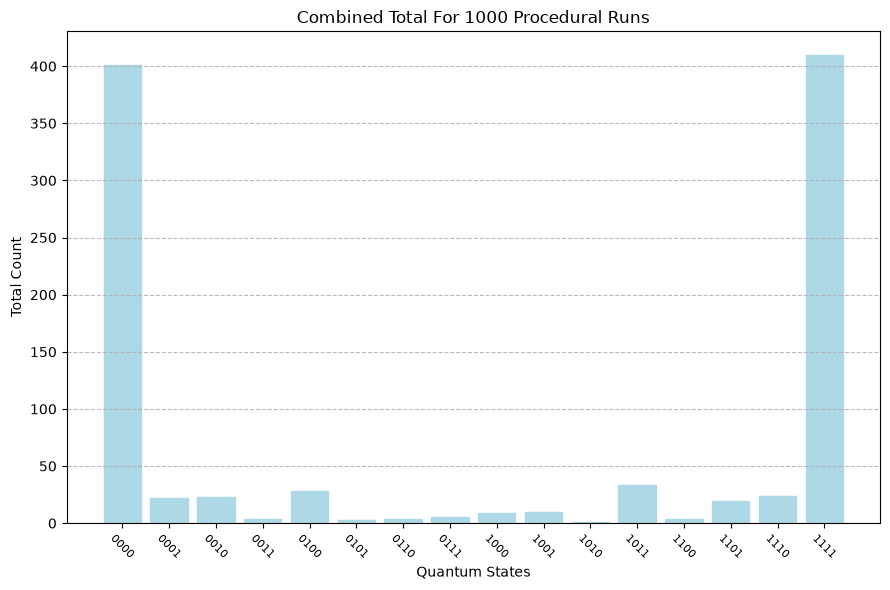

In [ ]:

total_counts.clear() #--- Reset the count
number_of_runs = 1000
print(f'Circuit:\n{base_circuit}\n')

for num in range(number_of_runs): #--- Run the following once per shot
  noisy_circuit = inject_errors(base_circuit) #--- Create the noisy_circuit
  final_circuit = create_final_circuit(base_circuit, find_errors()[0], find_errors()[1]) #--- Create a final circuit that models crosstalk | find_errors[0] creates list of flipped qubits, find_errors[1] creates list of noisy moments(slices)
  simulate(cirq.asymmetric_depolarize(0.0067)) #--- Simulate the final circuit | Set the type of noise inside the parenthesis
Graph() #--- Graph the results | Needs to be outside the run loop |

In [ ]:
import math
number_choices = 4
correct_choice = 3

"Get qubits to use in the circuit for Grover's algorithm."
nqubits = 2

def generate_binary_strings(number_choices):
    n = int(math.log(number_choices,2))
    binary_strings = []
    for i in range(2**n):
        binary_string = bin(i)[2:].zfill(n)
        binary_strings.append(binary_string)
    return binary_strings

ls = generate_binary_strings(number_choices)
print(ls)

def make_oracle(qubits, ancilla, marked_bitstring):
    """Implements the function {f(x) = 1 if x == x', f(x) = 0 if x != x'}."""
    # For x' = (1, 1), the oracle is just a Toffoli gate.
    # For a general x', we negate the zero bits and implement a Toffoli.

    # Negate zero bits, if necessary.
    for (q, bit) in zip(qubits, marked_bitstring):
        if not bit:
            yield (cirq.X(q))
    # Do the Toffoli. change this to MCX for a generalized oracle
    #yield (cirq.TOFFOLI(qubits[0], qubits[1], ancilla))
    # controls = len(qubits) -1
    controls = len(qubits)
    mcx_gate = cirq.ControlledGate(sub_gate=cirq.X, num_controls=controls)
    yield (mcx_gate(*qubits, ancilla))

    # Negate zero bits, if necessary.
    for (q, bit) in zip(qubits, marked_bitstring):
        if not bit:
            yield (cirq.X(q))

def grover_iteration(qubits, ancilla, marked_bitstring, reps=1):
    """Performs one round of the Grover iteration."""
    circuit = cirq.Circuit()

    # Create an equal superposition over input qubits.
    circuit.append(cirq.H.on_each(*qubits))

    # Put the output qubit in the |-⟩ state.
    circuit.append([cirq.X(ancilla), cirq.H(ancilla)])
    for r in range(reps):
        # Query the oracle.
        # circuit.append(oracle)
        for (q, bit) in zip(qubits, marked_bitstring):
            if not bit:
                circuit.append([cirq.X(q)])
        # Do the Toffoli. change this to MCX for a generalized oracle
        #yield (cirq.TOFFOLI(qubits[0], qubits[1], ancilla))
        # controls = len(qubits) -1
        controls = len(qubits)
        mcx_gate = cirq.ControlledGate(sub_gate=cirq.X, num_controls=controls)
        circuit.append([mcx_gate(*qubits, ancilla)])

        # Negate zero bits, if necessary.
        for (q, bit) in zip(qubits, marked_bitstring):
            if not bit:
                circuit.append([cirq.X(q)])

        # Construct Grover operator.
        circuit.append(cirq.H.on_each(*qubits))
        circuit.append(cirq.X.on_each(*qubits))

        # circuit.append(cirq.H.on(qubits[-1]))
        controls = len(qubits)
        mcx_gate = cirq.ControlledGate(sub_gate=cirq.X, num_controls=controls)
        mcx_op = mcx_gate(*qubits, ancilla)
        circuit.append(mcx_op)
        # circuit.append(cirq.H.on(qubits[-1]))

        circuit.append(cirq.X.on_each(*qubits))
        circuit.append(cirq.H.on_each(*qubits))

    # Measure the input register.
    circuit.append(cirq.measure(*qubits, key="result"))

    return circuit

# Get qubit registers.
qubits = cirq.LineQubit.range(nqubits)
ancilla = cirq.LineQubit(nqubits)

def get_marked_bitstring(correct_choice, nqubits):
    binary_representation = list(bin(correct_choice)[2:])
    marked_bitstring = [eval(i) for i in binary_representation]
    desired_length = nqubits
    marked_bitstring = [0] * (desired_length - len(marked_bitstring)) + marked_bitstring
    return marked_bitstring

marked_bitstring = get_marked_bitstring(correct_choice, nqubits)

"""Create the circuit for Grover's algorithm."""
# Make oracle (black box)
oracle = make_oracle(qubits, ancilla, marked_bitstring)

# Embed the oracle into a quantum circuit implementing Grover's algorithm.
base_circuit = grover_iteration(qubits, ancilla, marked_bitstring)

"""Simulate the circuit for Grover's algorithm and check the output."""
# Helper function.
def bitstring(bits):
    return "".join(str(int(b)) for b in bits)

def binary_labels(num_qubits):
    return [bin(x)[2:].zfill(num_qubits) for x in range(2 ** num_qubits)]

# Sample from the circuit a couple times.
simulator = cirq.Simulator()
result = simulator.run(base_circuit, repetitions = 1024)

# Look at the sampled bitstrings.
frequencies = result.histogram(key="result", fold_func=bitstring)
print('Sampled results:\n{}'.format(frequencies))

# Check if we actually found the secret value.
most_common_bitstring = frequencies.most_common(1)[0][0]
print("\nMost common bitstring: {}".format(most_common_bitstring))
print("Found a match? {}".format(most_common_bitstring == bitstring(marked_bitstring)))
print(base_circuit)

['00', '01', '10', '11']
Sampled results:
Counter({'11': 1024})

Most common bitstring: 11
Found a match? True
0: ───H───────@───H───X───@───X───H───M('result')───
              │           │           │
1: ───H───────@───H───X───@───X───H───M─────────────
              │           │
2: ───X───H───X───────────X─────────────────────────


Circuit:
0: ───H───────@───H───X───@───X───H───M('result')───
              │           │           │
1: ───H───────@───H───X───@───X───H───M─────────────
              │           │
2: ───X───H───X───────────X─────────────────────────


--- SIMULATION RESULTS ---

State |00⟩: Happened 1 times total = 1.00%
State |01⟩: Happened 0 times total = 0.00%
State |10⟩: Happened 0 times total = 0.00%
State |11⟩: Happened 99 times total = 99.00%


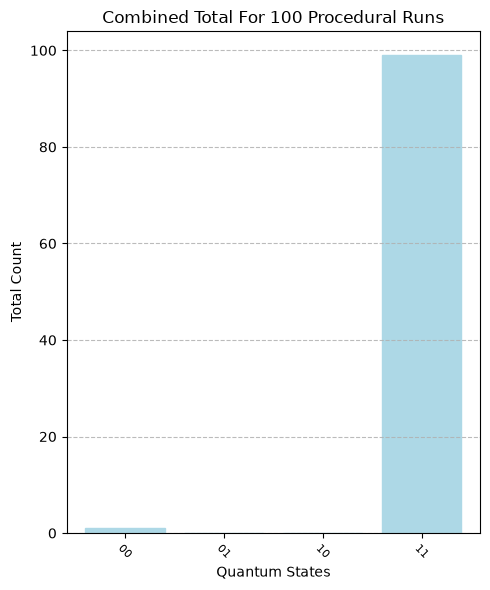

In [ ]:
number_of_qubits_in_the_circuit = nqubits
total_counts.clear() #--- Reset the count
number_of_runs = 100

# Update the global 'qubits' variable to include all qubits from the current base_circuit (Grover's),
# ensuring that find_errors() can correctly map all qubits to an index.
global qubits
qubits = sorted(list(base_circuit.all_qubits()))

for num in range(number_of_runs): #--- Run the following once per shot
  noisy_circuit = inject_errors(base_circuit) #--- Create the noisy_circuit
  final_circuit = create_final_circuit(base_circuit, find_errors()[0], find_errors()[1]) #--- Create a final circuit that models crosstalk | find_errors[0] creates list of flipped qubits, find_errors[1] creates list of noisy moments(slices)
  simulate(cirq.amplitude_damp(0.001)) #--- Simulate the final circuit | Set the type of noise inside the parenthesis
print(f'Circuit:\n{base_circuit}\n')
Graph() #--- Graph the results | Needs to be outside the run loop |

---
#Divider
---

Your Circuit:

0: ───H───@───@───@───M('result')───
          │   │   │   │
1: ───────X───┼───┼───M─────────────
              │   │   │
2: ───────────X───┼───M─────────────
                  │   │
3: ───────────────X───M─────────────


--- SIMULATION RESULTS ---

State |0000⟩: 497 times = 49.70%
State |0001⟩: 2 times = 0.20%
State |0010⟩: 6 times = 0.60%
State |0011⟩: 1 times = 0.10%
State |0100⟩: 2 times = 0.20%
State |0101⟩: 0 times = 0.00%
State |0110⟩: 1 times = 0.10%
State |0111⟩: 3 times = 0.30%
State |1000⟩: 1 times = 0.10%
State |1001⟩: 1 times = 0.10%
State |1010⟩: 0 times = 0.00%
State |1011⟩: 3 times = 0.30%
State |1100⟩: 1 times = 0.10%
State |1101⟩: 5 times = 0.50%
State |1110⟩: 0 times = 0.00%
State |1111⟩: 477 times = 47.70%


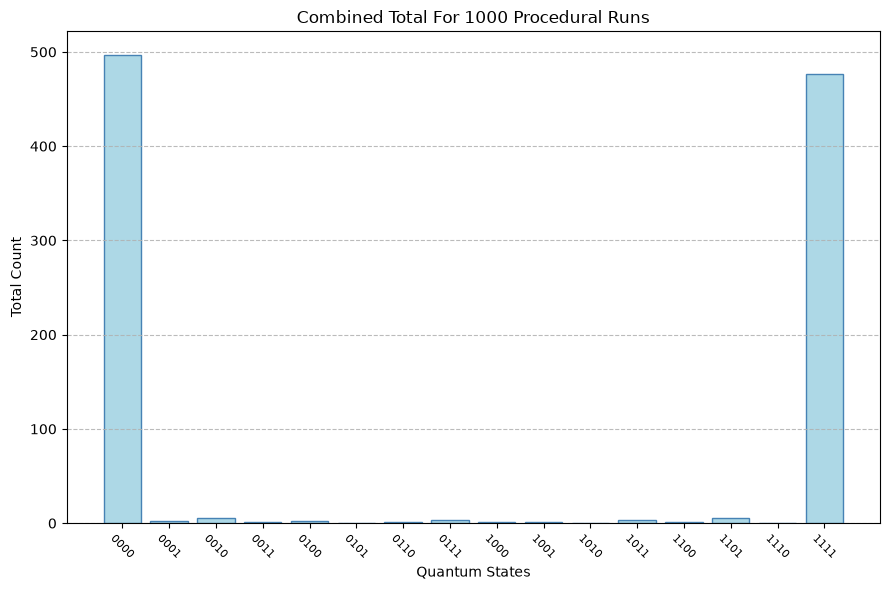

In [ ]:
"""
Corrected NISQ simulation with crosstalk modeling.

Key fixes vs. the original draft:
  1. inject_errors / find_errors / create_final_circuit are merged into a
     single function, build_shot_circuit(). Everything -- bit-flip,
     depolarizing, amplitude damping, AND the crosstalk that depends on
     "which qubits flipped" -- is now decided from ONE set of random
     draws per shot, so crosstalk actually reacts to the noise that's in
     the circuit being simulated, not to a separately-redrawn trajectory.
  2. Removed the accidentally-nested inner loop that was re-running the
     whole circuit's noise injection after every moment.
  3. Crosstalk probability is clamped to [0, 1] and guarded against
     divide-by-zero.
  4. Qubit count / labels are passed as arguments instead of relying on
     mutable globals, so swapping circuits (e.g. to Grover's algorithm)
     can't leave stale state behind.
"""

import cirq
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ================= Parameters =================
number_of_qubits_in_the_circuit = 4
number_of_runs = 1000
base_noise = 0.00036       # background error rate (idle qubits), decimal
high_noise = 0.0014        # elevated error rate for qubits under a gate this moment
distance_between_qubits = 2  # micrometers
amplitude_damp_chance = 0.0001

# Gates that count as "actively driven" this moment -> use high_noise
# instead of base_noise, and are the source of crosstalk to neighbors.
LOUD_GATE_TYPES = (
    cirq.XPowGate,
    cirq.YPowGate,
    cirq.ZPowGate,
    cirq.HPowGate,
    cirq.CXPowGate,
    cirq.PhasedXPowGate,
)

# ================= Build Circuit =================
qubits = cirq.LineQubit.range(number_of_qubits_in_the_circuit)
base_circuit = cirq.Circuit([
    cirq.H(qubits[0]),
    cirq.CNOT(qubits[0], qubits[1]),
    cirq.CNOT(qubits[0], qubits[2]),
    cirq.CNOT(qubits[0], qubits[3]),
    cirq.measure(*qubits, key='result'),
])

print(f"Your Circuit:\n\n{base_circuit}\n")


# ================= Core noise + crosstalk builder =================
def build_shot_circuit(original_circuit, all_qubits):
    """
    Builds ONE fully-noisy circuit for a single simulation shot.

    For every non-measurement moment in `original_circuit`:
      - appends the ideal gate(s) for that moment
      - appends bit-flip + depolarizing channels, using high_noise for
        qubits actively driven this moment and base_noise otherwise
      - appends an amplitude-damping channel on every qubit
      - draws (once, here) which qubits actually flip this shot, using
        the same error_rate values just used to build the channels above
      - appends a crosstalk moment: qubits near a flipped qubit get a
        bit-flip probability that falls off with distance; qubits that
        flipped themselves get probability 1.0 (already-realized error)

    Because the "did it flip" draw happens in the same loop, using the
    same error rates, as the channels themselves, the crosstalk this shot
    is always consistent with the noise actually present in the circuit.

    Returns a single cirq.Circuit ready to hand to a Simulator.
    """
    circuit = cirq.Circuit()

    for moment in original_circuit:
        circuit.append(moment)

        if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
            continue

        active_loud_qubits = {
            q for op in moment if isinstance(op.gate, LOUD_GATE_TYPES) for q in op.qubits
        }

        bit_flip_ops = []
        depolarize_ops = []
        flipped_qubit_indices = []

        for q_idx, q in enumerate(all_qubits):
            error_rate = high_noise if q in active_loud_qubits else base_noise
            bit_flip_ops.append(cirq.bit_flip(p=error_rate)(q))
            depolarize_ops.append(cirq.depolarize(p=error_rate)(q))
            if np.random.rand() < error_rate:
                flipped_qubit_indices.append(q_idx)

        #circuit.append(cirq.Moment(bit_flip_ops))
        circuit.append(cirq.Moment(depolarize_ops))
        circuit.append(cirq.Moment(cirq.amplitude_damp(amplitude_damp_chance)(q) for q in all_qubits))

        # --- Crosstalk, driven by the SAME flip draw as above ---
        crosstalk_ops = []
        for q_idx, q in enumerate(all_qubits):
            if q_idx in flipped_qubit_indices:
                crosstalk_p = 1.0  # this qubit already flipped -- treat as certain
            elif flipped_qubit_indices:
                distances = [
                    abs(q_idx - flipped_idx) * distance_between_qubits
                    for flipped_idx in flipped_qubit_indices
                ]
                shortest = max(min(distances), 1e-9)  # guard divide-by-zero
                crosstalk_p = min(1.0, 1.0 / (shortest ** 2))  # clamp to a valid probability
            else:
                crosstalk_p = 0.0
            crosstalk_ops.append(cirq.bit_flip(p=crosstalk_p)(q))
        circuit.append(cirq.Moment(crosstalk_ops))

    return circuit


# ================= Simulate + collect results =================
total_counts = Counter()


def simulate(circuit, type_of_noise=None):
    """Runs `circuit` once (1 shot) and folds the result into total_counts."""
    sim = cirq.Simulator(noise=type_of_noise) if type_of_noise is not None else cirq.Simulator()
    result = sim.run(circuit)
    total_counts.update(result.histogram(key='result'))


def graph(num_qubits, num_runs):
    """Bar chart of measured outcome frequencies across all shots so far."""
    print("\n--- SIMULATION RESULTS ---\n")

    total_possible_states = 2 ** num_qubits
    labels, values = [], []
    for outcome in range(total_possible_states):
        binary_string = format(outcome, f"0{num_qubits}b")
        labels.append(binary_string)
        actual_count = total_counts.get(outcome, 0)
        values.append(actual_count)
        print(f"State |{binary_string}⟩: {actual_count} times = {(actual_count / num_runs) * 100:.2f}%")

    plt.figure(figsize=(1 + 2 * num_qubits, 6))
    plt.bar(labels, values, color="lightblue", edgecolor="steelblue")
    plt.title(f"Combined Total For {num_runs} Procedural Runs")
    plt.xlabel("Quantum States")
    plt.ylabel("Total Count")
    plt.xticks(rotation=315, fontsize=8)
    plt.grid(axis="y", linestyle="--", alpha=0.85)
    plt.tight_layout()
    plt.show()


def run_experiment(circuit_template, all_qubits, num_runs, extra_noise=None):
    """
    Runs `num_runs` independent shots. Each shot gets its OWN fresh noisy
    circuit (its own random crosstalk realization) via build_shot_circuit,
    which is the fix for the original bug of reusing/mismatching draws
    across shots.
    """
    total_counts.clear()
    for _ in range(num_runs):
        shot_circuit = build_shot_circuit(circuit_template, all_qubits)
        #print(shot_circuit)
        simulate(shot_circuit, extra_noise)
    graph(len(all_qubits), num_runs)


# ================= Run it =================
if __name__ == "__main__":

    run_experiment(
        base_circuit,
        qubits,
        number_of_runs,
        extra_noise=None,
    )

Your Circuit:

0: ───H───@───@───@───M('result')───
          │   │   │   │
1: ───────X───┼───┼───M─────────────
              │   │   │
2: ───────────X───┼───M─────────────
                  │   │
3: ───────────────X───M─────────────

Circuit:
0: ───H───@───@───@───M('result')───
          │   │   │   │
1: ───────X───┼───┼───M─────────────
              │   │   │
2: ───────────X───┼───M─────────────
                  │   │
3: ───────────────X───M─────────────


--- SIMULATION RESULTS ---

State |0000⟩: 703 times = 35.15%
State |0001⟩: 52 times = 2.60%
State |0010⟩: 56 times = 2.80%
State |0011⟩: 32 times = 1.60%
State |0100⟩: 81 times = 4.05%
State |0101⟩: 17 times = 0.85%
State |0110⟩: 54 times = 2.70%
State |0111⟩: 42 times = 2.10%
State |1000⟩: 44 times = 2.20%
State |1001⟩: 55 times = 2.75%
State |1010⟩: 9 times = 0.45%
State |1011⟩: 72 times = 3.60%
State |1100⟩: 30 times = 1.50%
State |1101⟩: 57 times = 2.85%
State |1110⟩: 50 times = 2.50%
State |1111⟩: 646 times = 32.30%


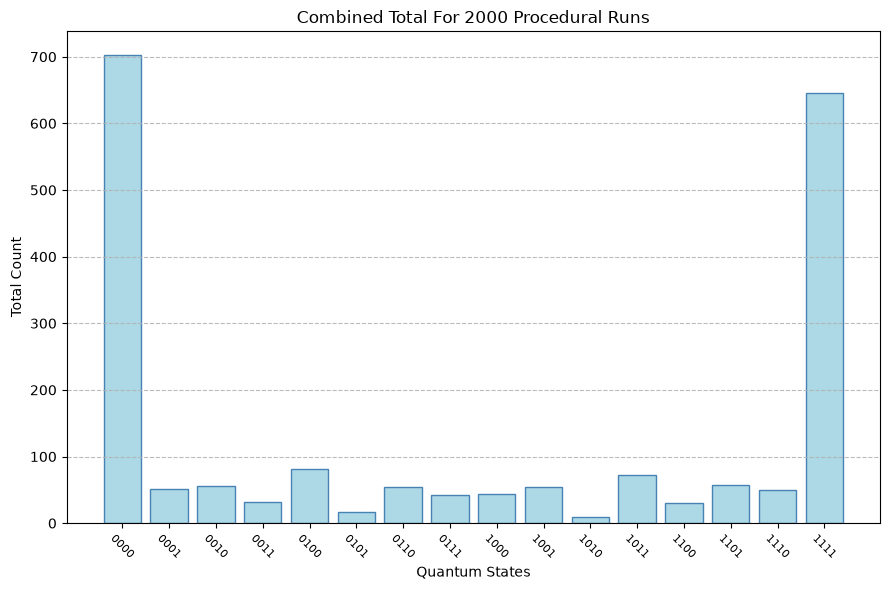

In [ ]:


import cirq
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ================= Parameters =================
number_of_qubits_in_the_circuit = 4
number_of_runs = 2000
base_noise = 0.0036       # background error rate (idle qubits), decimal
high_noise = 0.034        # elevated error rate for qubits under a gate this moment
distance_between_qubits = 2  # micrometers
amplitude_damp_chance = 0.0001

# Gates that count as "actively driven" this moment -> use high_noise
# instead of base_noise, and are the source of crosstalk to neighbors.
LOUD_GATE_TYPES = (
    cirq.XPowGate,
    cirq.YPowGate,
    cirq.ZPowGate,
    cirq.HPowGate,
    cirq.CXPowGate,
    cirq.PhasedXPowGate,
)

# ================= Build Circuit =================
qubits = cirq.LineQubit.range(number_of_qubits_in_the_circuit)
base_circuit = cirq.Circuit([
    cirq.H(qubits[0]),
    cirq.CNOT(qubits[0], qubits[1]),
    cirq.CNOT(qubits[0], qubits[2]),
    cirq.CNOT(qubits[0], qubits[3]),
    cirq.measure(*qubits, key='result'),
])

print(f"Your Circuit:\n\n{base_circuit}\n")


# ================= Core noise + crosstalk builder =================
def build_shot_circuit(original_circuit, all_qubits):
    """
    Builds ONE fully-noisy circuit for a single simulation shot.

    For every non-measurement moment in `original_circuit`:
      - appends the ideal gate(s) for that moment
      - appends bit-flip + depolarizing channels, using high_noise for
        qubits actively driven this moment and base_noise otherwise
      - appends an amplitude-damping channel on every qubit
      - draws (once, here) which qubits actually flip this shot, using
        the same error_rate values just used to build the channels above
      - appends a crosstalk moment: qubits near a flipped qubit get a
        bit-flip probability that falls off with distance; qubits that
        flipped themselves get probability 1.0 (already-realized error)

    Because the "did it flip" draw happens in the same loop, using the
    same error rates, as the channels themselves, the crosstalk this shot
    is always consistent with the noise actually present in the circuit.

    Returns a single cirq.Circuit ready to hand to a Simulator.
    """
    circuit = cirq.Circuit()

    for moment in original_circuit:
        circuit.append(moment)

        if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
            continue

        active_loud_qubits = {
            q for op in moment if isinstance(op.gate, LOUD_GATE_TYPES) for q in op.qubits
        }

        bit_flip_ops = []
        depolarize_ops = []
        flipped_qubit_indices = []

        for q_idx, q in enumerate(all_qubits):
            error_rate = high_noise if q in active_loud_qubits else base_noise
            bit_flip_ops.append(cirq.bit_flip(p=error_rate)(q))
            depolarize_ops.append(cirq.depolarize(p=error_rate)(q))
            if np.random.rand() < error_rate:
                flipped_qubit_indices.append(q_idx)

        #circuit.append(cirq.Moment(bit_flip_ops))
        circuit.append(cirq.Moment(depolarize_ops))
        circuit.append(cirq.Moment(cirq.amplitude_damp(amplitude_damp_chance)(q) for q in all_qubits))

        # --- Crosstalk, driven by the SAME flip draw as above ---
        crosstalk_ops = []
        for q_idx, q in enumerate(all_qubits):
            if q_idx in flipped_qubit_indices:
                crosstalk_p = 1.0  # this qubit already flipped -- treat as certain
            elif flipped_qubit_indices:
                distances = [
                    abs(q_idx - flipped_idx) * distance_between_qubits
                    for flipped_idx in flipped_qubit_indices
                ]
                shortest = max(min(distances), 1e-9)  # guard divide-by-zero
                crosstalk_p = min(1.0, 1.0 / (shortest ** 2))  # clamp to a valid probability
            else:
                crosstalk_p = 0.0
            crosstalk_ops.append(cirq.bit_flip(p=crosstalk_p)(q))
        circuit.append(cirq.Moment(crosstalk_ops))

    return circuit


# ================= Simulate + collect results =================
total_counts = Counter()


def simulate(circuit):
    """
    Runs `circuit` once (1 shot) and folds the result into total_counts.

    IMPORTANT: circuit here is the output of build_shot_circuit, which
    already contains every noise channel we want (bit-flip, depolarizing,
    amplitude damping, crosstalk). Do NOT also pass a `noise=` model to
    cirq.Simulator -- that applies an EXTRA layer of noise to every single
    operation already in the circuit, including the noise operations
    themselves, which silently multiplies your error rates far beyond
    base_noise/high_noise. Use a bare Simulator here.
    """
    sim = cirq.Simulator()
    result = sim.run(circuit)
    total_counts.update(result.histogram(key='result'))


def graph(num_qubits, num_runs):
    """Bar chart of measured outcome frequencies across all shots so far."""
    print("\n--- SIMULATION RESULTS ---\n")

    total_possible_states = 2 ** num_qubits
    labels, values = [], []
    for outcome in range(total_possible_states):
        binary_string = format(outcome, f"0{num_qubits}b")
        labels.append(binary_string)
        actual_count = total_counts.get(outcome, 0)
        values.append(actual_count)
        print(f"State |{binary_string}⟩: {actual_count} times = {(actual_count / num_runs) * 100:.2f}%")

    plt.figure(figsize=(1 + 2 * num_qubits, 6))
    plt.bar(labels, values, color="lightblue", edgecolor="steelblue")
    plt.title(f"Combined Total For {num_runs} Procedural Runs")
    plt.xlabel("Quantum States")
    plt.ylabel("Total Count")
    plt.xticks(rotation=315, fontsize=8)
    plt.grid(axis="y", linestyle="--", alpha=0.85)
    plt.tight_layout()
    plt.show()


def run_experiment(circuit_template, all_qubits, num_runs):
    """
    Runs `num_runs` independent shots. Each shot gets its OWN fresh noisy
    circuit (its own random crosstalk realization) via build_shot_circuit,
    which is the fix for the original bug of reusing/mismatching draws
    across shots.
    """
    total_counts.clear()
    for _ in range(num_runs):
        shot_circuit = build_shot_circuit(circuit_template, all_qubits)
        #print(shot_circuit)
        simulate(shot_circuit)
    graph(len(all_qubits), num_runs)


# ================= Run it =================
if __name__ == "__main__":
    print(f"Circuit:\n{base_circuit}\n")
    run_experiment(base_circuit, qubits, number_of_runs)

#Divider 2


Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...
Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...

Training samples: 2550  (holdout: 450, real-world test: 1000)
Training MLP error-mitigation model...

=== Real-world NISQ evaluation (held-out test set) ===
Raw noisy bitstring accuracy:       43.00%
Model-corrected bitstring accuracy: 50.00%
Improvement:                        +7.00 percentage points

  qubit 0: raw=49.10%  corrected=50.00%
  qubit 1: raw=48.20%  corrected=50.00%
  qubit 2: raw=50.00%  corrected=50.00%
  qubit 3: raw=48.90%  corrected=50.00%


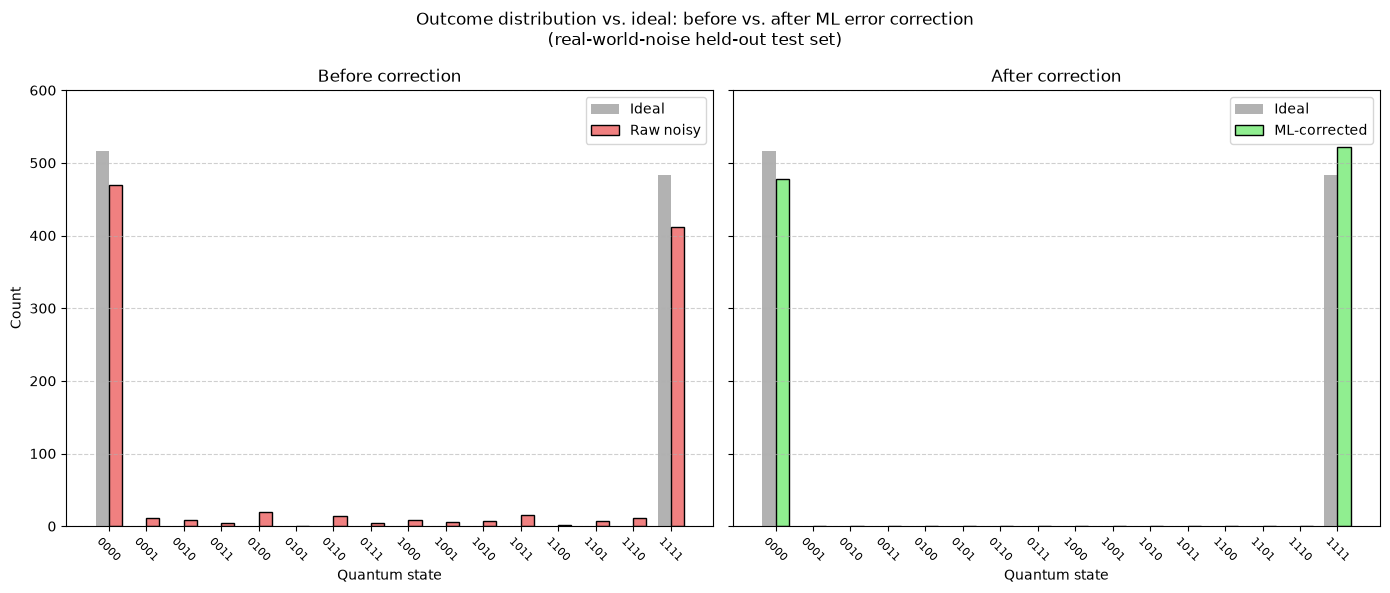

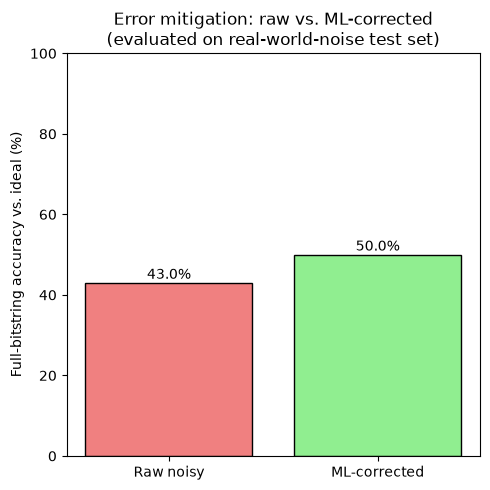

In [141]:
"""
Machine-learning error-mitigation model for the NISQ simulator.

Design:
  - LOW_NOISE_CONFIG represents a clean, low-error "calibration" baseline
    -- close to what an idealized/well-behaved NISQ device would look
    like. This makes up most of the training data, so the model mostly
    learns clean, easy-to-decode examples first.
  - REAL_WORLD_CONFIG represents a realistic, higher-error NISQ device
    (bigger base/high error rates, more amplitude damping, tighter qubit
    spacing so crosstalk bites harder). This is folded into training in
    a smaller proportion, and used as a completely separate held-out test
    set, so we can honestly measure how well the model generalizes to
    "real world" noise it wasn't trained exclusively on.

This reuses the exact same noise + crosstalk model from nisq_corrected.py
(build_shot_circuit), just parameterized by a NoiseConfig so we can swap
between the low-noise baseline and the real-world profile.

TODO(team):
  - Once actual device characterization data is available, replace
    REAL_WORLD_CONFIG's numbers with calibrated values (T1/T2, readout
    error, measured crosstalk) instead of the placeholder scale-up used
    here.
  - Try a richer feature set than just the raw noisy bitstring (e.g.
    per-qubit "was this a loud qubit this shot" flags, syndrome-style
    parity checks) -- for a small circuit like this, the model can only
    learn as much structure as the input features expose.
  - Swap MLPClassifier for a purpose-built neural network (the project's
    July 28 - Aug 3 milestone) once the team has settled on architecture.
"""

from __future__ import annotations

from dataclasses import dataclass

import cirq
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

LOUD_GATE_TYPES = (
    cirq.XPowGate,
    cirq.YPowGate,
    cirq.ZPowGate,
    cirq.HPowGate,
    cirq.CXPowGate,
    cirq.PhasedXPowGate,
)


@dataclass
class NoiseConfig:
    name: str
    base_noise: float          # background error rate on idle qubits
    high_noise: float          # error rate on actively-driven qubits
    amplitude_damp_chance: float
    distance_between_qubits: float  # micrometers; smaller = stronger crosstalk


# "Low error percentage" baseline -- bulk of the training data.
LOW_NOISE_CONFIG = NoiseConfig(
    name="low_noise_baseline",
    base_noise=0.00005,
    high_noise=0.0002,
    amplitude_damp_chance=0.00002,
    distance_between_qubits=4,
)

# Higher, more realistic error rates -- mimics an actual NISQ device.
# Placeholder scale-up until calibrated against real hardware data.
REAL_WORLD_CONFIG = NoiseConfig(
    name="real_world_nisq",
    base_noise=0.002,
    high_noise=0.01,
    amplitude_damp_chance=0.001,
    distance_between_qubits=2,
)


# ================= Noise + crosstalk model (same as nisq_corrected.py) =================
def build_shot_circuit(original_circuit, all_qubits, config: NoiseConfig):
    """Builds one noisy shot circuit under the given NoiseConfig."""
    circuit = cirq.Circuit()
    for moment in original_circuit:
        circuit.append(moment)
        if any(isinstance(op.gate, cirq.MeasurementGate) for op in moment):
            continue

        active_loud_qubits = {
            q for op in moment if isinstance(op.gate, LOUD_GATE_TYPES) for q in op.qubits
        }

        bit_flip_ops, depolarize_ops, flipped_qubit_indices = [], [], []
        for q_idx, q in enumerate(all_qubits):
            rate = config.high_noise if q in active_loud_qubits else config.base_noise
            bit_flip_ops.append(cirq.bit_flip(p=rate)(q))
            depolarize_ops.append(cirq.depolarize(p=rate)(q))
            if np.random.rand() < rate:
                flipped_qubit_indices.append(q_idx)

        #circuit.append(cirq.Moment(bit_flip_ops))
        circuit.append(cirq.Moment(depolarize_ops))
        circuit.append(cirq.Moment(cirq.amplitude_damp(config.amplitude_damp_chance)(q) for q in all_qubits))

        crosstalk_ops = []
        for q_idx, q in enumerate(all_qubits):
            if q_idx in flipped_qubit_indices:
                crosstalk_p = 1.0
            elif flipped_qubit_indices:
                distances = [
                    abs(q_idx - flipped_idx) * config.distance_between_qubits
                    for flipped_idx in flipped_qubit_indices
                ]
                shortest = max(min(distances), 1e-9)
                crosstalk_p = min(1.0, 1.0 / (shortest ** 2))
            else:
                crosstalk_p = 0.0
            crosstalk_ops.append(cirq.bit_flip(p=crosstalk_p)(q))
        circuit.append(cirq.Moment(crosstalk_ops))

    return circuit


# ================= Dataset generation =================
def generate_dataset(base_circuit, qubits, config: NoiseConfig, num_samples: int, ideal_simulator=None):
    """
    Returns (X, y):
      X = [base_noise, high_noise, amplitude_damp_chance, distance_between_qubits, *noisy_bitstring]
      y = ideal_bitstring (ground truth, from the noiseless circuit)
    """
    ideal_simulator = ideal_simulator or cirq.Simulator()
    noisy_simulator = cirq.Simulator()
    config_features = [
        config.base_noise,
        config.high_noise,
        config.amplitude_damp_chance,
        config.distance_between_qubits,
    ]

    X_rows, y_rows = [], []
    for _ in range(num_samples):
        shot_circuit = build_shot_circuit(base_circuit, qubits, config)
        noisy_bits = noisy_simulator.run(shot_circuit).measurements['result'][0]
        ideal_bits = ideal_simulator.run(base_circuit).measurements['result'][0]

        X_rows.append(config_features + list(noisy_bits))
        y_rows.append(list(ideal_bits))

    return np.array(X_rows, dtype=float), np.array(y_rows, dtype=float)


def bitstring_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Fraction of samples where EVERY bit matches the ideal bitstring."""
    return float(np.mean(np.all(y_true == y_pred, axis=1)))


def per_bit_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> np.ndarray:
    """Per-qubit accuracy, useful for seeing which qubits are hardest to correct."""
    return np.mean(y_true == y_pred, axis=0)


def bits_to_state_indices(bit_rows: np.ndarray) -> np.ndarray:
    """Converts an (N, num_qubits) array of 0/1 rows into an (N,) array of integer state indices."""
    num_qubits = bit_rows.shape[1]
    weights = 2 ** np.arange(num_qubits - 1, -1, -1)
    return bit_rows.astype(int).dot(weights)


def state_indices_to_bits(state_indices: np.ndarray, num_qubits: int) -> np.ndarray:
    """Inverse of bits_to_state_indices: turns integer class labels back into 0/1 bit rows."""
    rows = [[int(b) for b in format(int(idx), f"0{num_qubits}b")] for idx in state_indices]
    return np.array(rows, dtype=float)


def plot_before_after_histograms(y_ideal: np.ndarray, y_noisy: np.ndarray, y_corrected: np.ndarray, num_qubits: int):
    """
    Side-by-side histograms over every computational basis state (|0000>
    ... |1111>), comparing the ideal distribution against the raw noisy
    results (before correction) and the ML-corrected results (after
    correction). Same y-axis scale on both so the improvement is visually
    comparable.
    """
    num_states = 2 ** num_qubits
    labels = [format(i, f"0{num_qubits}b") for i in range(num_states)]

    ideal_counts = np.bincount(bits_to_state_indices(y_ideal), minlength=num_states)
    noisy_counts = np.bincount(bits_to_state_indices(y_noisy), minlength=num_states)
    corrected_counts = np.bincount(bits_to_state_indices(y_corrected), minlength=num_states)

    y_max = max(ideal_counts.max(), noisy_counts.max(), corrected_counts.max()) * 1.15
    x = np.arange(num_states)
    width = 0.35

    fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    ax_before.bar(x - width / 2, ideal_counts, width, label="Ideal", color="gray", alpha=0.6)
    ax_before.bar(x + width / 2, noisy_counts, width, label="Raw noisy", color="lightcoral", edgecolor="black")
    ax_before.set_title("Before correction")
    ax_before.set_xlabel("Quantum state")
    ax_before.set_ylabel("Count")
    ax_before.set_xticks(x)
    ax_before.set_xticklabels(labels, rotation=315, fontsize=8)
    ax_before.set_ylim(0, y_max)
    ax_before.legend()
    ax_before.grid(axis="y", linestyle="--", alpha=0.6)

    ax_after.bar(x - width / 2, ideal_counts, width, label="Ideal", color="gray", alpha=0.6)
    ax_after.bar(x + width / 2, corrected_counts, width, label="ML-corrected", color="lightgreen", edgecolor="black")
    ax_after.set_title("After correction")
    ax_after.set_xlabel("Quantum state")
    ax_after.set_xticks(x)
    ax_after.set_xticklabels(labels, rotation=315, fontsize=8)
    ax_after.legend()
    ax_after.grid(axis="y", linestyle="--", alpha=0.6)

    fig.suptitle("Outcome distribution vs. ideal: before vs. after ML error correction\n(real-world-noise held-out test set)")
    plt.tight_layout()
    plt.show()


# ================= Main training + evaluation pipeline =================
def main():
    number_of_qubits = 4
    qubits = cirq.LineQubit.range(number_of_qubits)
    base_circuit = cirq.Circuit([
        cirq.H(qubits[0]),
        cirq.CNOT(qubits[0], qubits[1]),
        cirq.CNOT(qubits[0], qubits[2]),
        cirq.CNOT(qubits[0], qubits[3]),
        cirq.measure(*qubits, key='result'),
    ])

    ideal_sim = cirq.Simulator()

    print("Generating LOW-noise training data (clean baseline)...")
    X_low, y_low = generate_dataset(base_circuit, qubits, LOW_NOISE_CONFIG, num_samples=2400, ideal_simulator=ideal_sim)

    print("Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...")
    X_real_train, y_real_train = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, num_samples=600, ideal_simulator=ideal_sim)

    print("Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...")
    X_real_test, y_real_test = generate_dataset(base_circuit, qubits, REAL_WORLD_CONFIG, num_samples=1000, ideal_simulator=ideal_sim)

    # Training set: mostly low-noise (the "low error percentage" data),
    # with a smaller slice of real-world-noise data mixed in so the model
    # has at least seen the harder error regime it'll be evaluated on.
    X_train = np.vstack([X_low, X_real_train])
    y_train = np.vstack([y_low, y_real_train])
    X_train, X_holdout, y_train, y_holdout = train_test_split(X_train, y_train, test_size=0.15, random_state=0)

    print(f"\nTraining samples: {len(X_train)}  (holdout: {len(X_holdout)}, real-world test: {len(X_real_test)})")

    print("Training MLP error-mitigation model...")
    # IMPORTANT: this circuit's ideal outcomes are perfectly correlated
    # across qubits (only |0000> or |1111> are ever valid) -- so instead
    # of training 4 independent per-bit classifiers (which have no way to
    # know the bits are linked, and whose small individual biases compound
    # into wildly overcorrecting toward one state), we train ONE classifier
    # over the joint outcome state. This lets the model learn the correct
    # *proportional* asymmetry from the noise model (e.g. amplitude damping
    # only ever pulling 1->0) instead of an all-or-nothing collapse.
    y_train_labels = bits_to_state_indices(y_train)
    model = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=0)
    model.fit(X_train, y_train_labels)

    # --- Evaluate on the held-out real-world test set ---
    noisy_bits_test = X_real_test[:, -number_of_qubits:]
    raw_acc = bitstring_accuracy(y_real_test, noisy_bits_test)

    corrected_labels_test = model.predict(X_real_test)
    corrected_bits_test = state_indices_to_bits(corrected_labels_test, number_of_qubits)
    corrected_acc = bitstring_accuracy(y_real_test, corrected_bits_test)

    raw_per_bit = per_bit_accuracy(y_real_test, noisy_bits_test)
    corrected_per_bit = per_bit_accuracy(y_real_test, corrected_bits_test)

    print("\n=== Real-world NISQ evaluation (held-out test set) ===")
    print(f"Raw noisy bitstring accuracy:       {raw_acc * 100:.2f}%")
    print(f"Model-corrected bitstring accuracy: {corrected_acc * 100:.2f}%")
    print(f"Improvement:                        {(corrected_acc - raw_acc) * 100:+.2f} percentage points\n")
    for i in range(number_of_qubits):
        print(f"  qubit {i}: raw={raw_per_bit[i] * 100:5.2f}%  corrected={corrected_per_bit[i] * 100:5.2f}%")

    # --- Plots ---
    plot_before_after_histograms(y_real_test, noisy_bits_test, corrected_bits_test, number_of_qubits)

    plt.figure(figsize=(5, 5))
    plt.bar(["Raw noisy", "ML-corrected"], [raw_acc * 100, corrected_acc * 100],
            color=["lightcoral", "lightgreen"], edgecolor="black")
    plt.ylabel("Full-bitstring accuracy vs. ideal (%)")
    plt.title("Error mitigation: raw vs. ML-corrected\n(evaluated on real-world-noise test set)")
    plt.ylim(0, 100)
    for i, v in enumerate([raw_acc * 100, corrected_acc * 100]):
        plt.text(i, v + 1, f"{v:.1f}%", ha="center")
    plt.tight_layout()
    plt.show()


#if __name__ == "__main__":
    main()

Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...
Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...

Training samples: 2550  (holdout: 450, real-world test: 1000)
Training MLP error-mitigation model...

=== Real-world NISQ evaluation (held-out test set) ===
Raw noisy bitstring accuracy:       47.40%
Model-corrected bitstring accuracy: 45.60%
Improvement:                        -1.80 percentage points

  qubit 0: raw=53.60%  corrected=45.60%
  qubit 1: raw=53.20%  corrected=45.60%
  qubit 2: raw=54.10%  corrected=45.60%
  qubit 3: raw=52.50%  corrected=45.60%


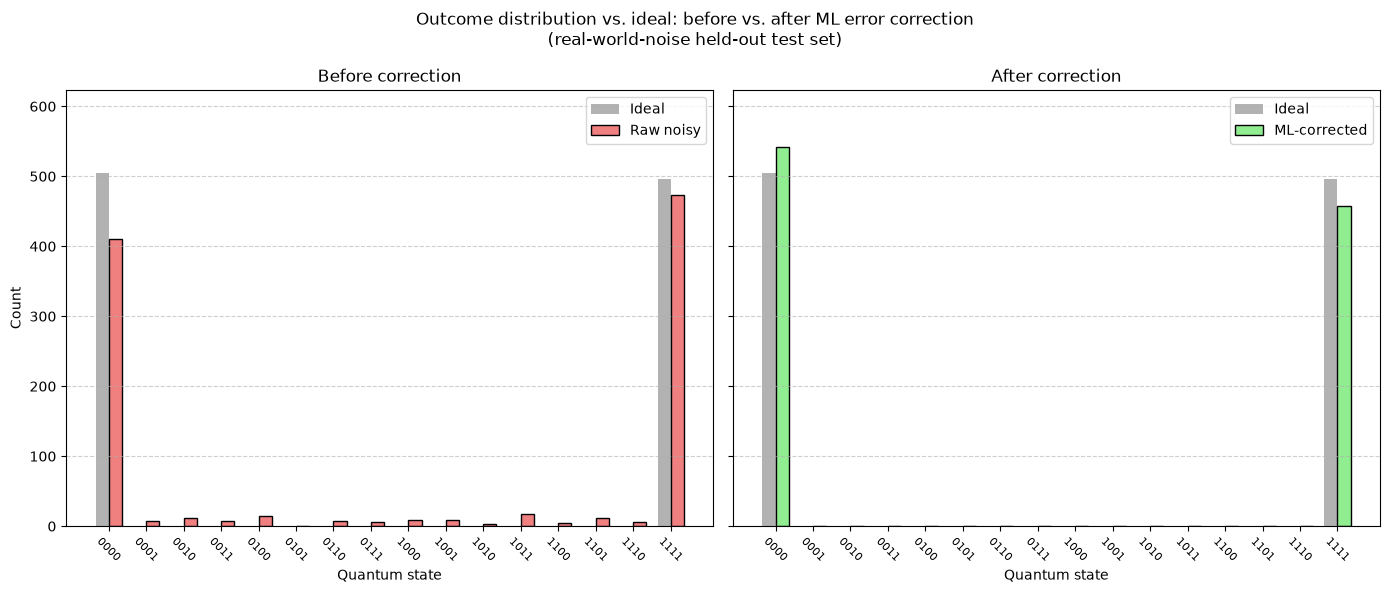

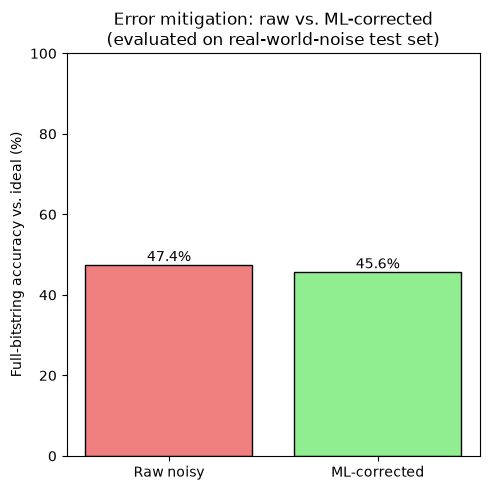

Generating LOW-noise training data (clean baseline)...
Generating REAL-WORLD-noise training data (mimics actual NISQ hardware)...
Generating a SEPARATE, held-out REAL-WORLD-noise test set (not used in training)...

Training samples: 2550  (holdout: 450, real-world test: 1000)
Training MLP error-mitigation model...

=== Real-world NISQ evaluation (held-out test set) ===
Raw noisy bitstring accuracy:       42.70%
Model-corrected bitstring accuracy: 49.50%
Improvement:                        +6.80 percentage points

  qubit 0: raw=49.50%  corrected=49.50%
  qubit 1: raw=47.80%  corrected=49.50%
  qubit 2: raw=48.70%  corrected=49.50%
  qubit 3: raw=49.30%  corrected=49.50%


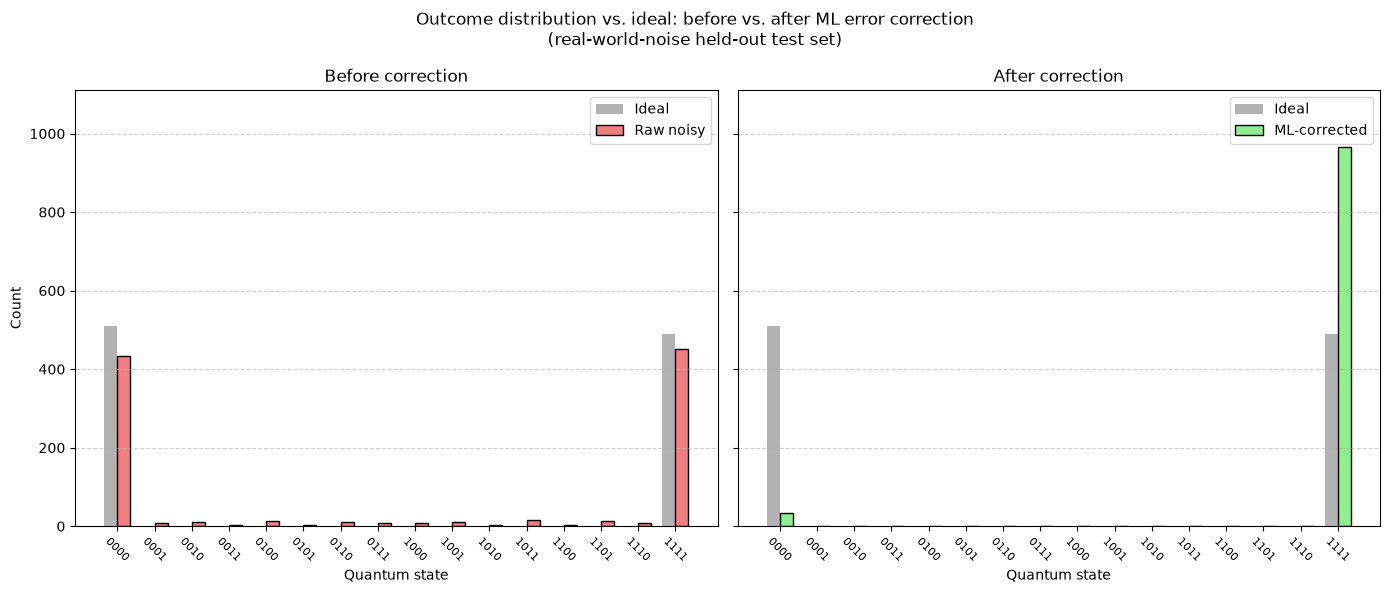

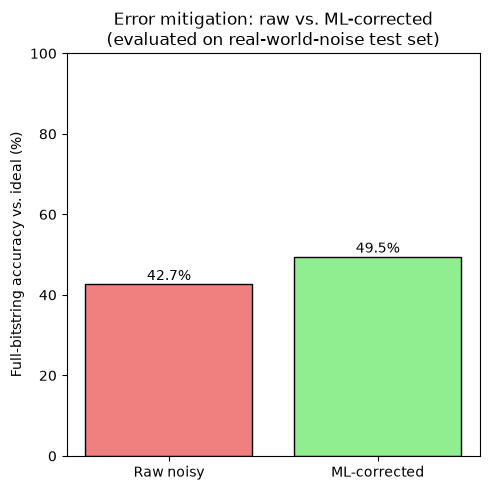

In [143]:
main()
main()